In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score,ConfusionMatrixDisplay
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding,pipeline
from datasets import Dataset

# Data Understanding & Preprocessing

## Loading Dataset 

In [2]:
bbc_news_og_ds = pd.read_csv("/kaggle/input/datasets/vidhyashinde/bbc-news-dataset/BBC_Capstone_Dataset.csv")

In [3]:
bbc_news = bbc_news_og_ds.copy()

In [4]:
bbc_news.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


In [5]:
bbc_news.shape

(2225, 2)

In [6]:
bbc_news.columns

Index(['category', 'text'], dtype='object')

In [7]:
bbc_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  2225 non-null   object
 1   text      2225 non-null   object
dtypes: object(2)
memory usage: 34.9+ KB


## Visualizing the category column

In [8]:
bbc_news['category'].value_counts()

category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

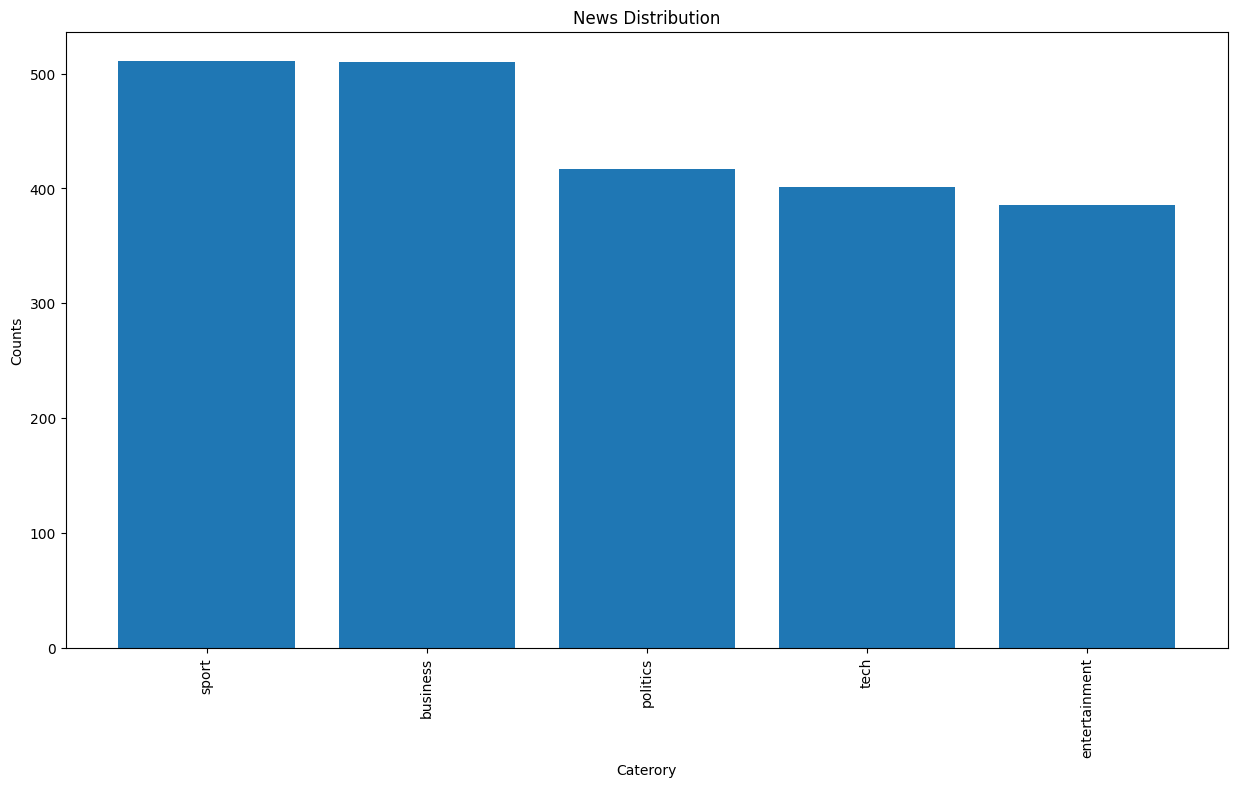

In [9]:
category = bbc_news['category'].value_counts()
category_name = category.index.to_list()
category_counts = category.values.tolist()
plt.figure(figsize=(15,8))
plt.bar(category_name,category_counts)
plt.xlabel('Caterory')
plt.xticks(rotation=90)
plt.ylabel('Counts')
plt.title("News Distribution")
plt.show()

## Text Cleaning
In this step we will convert text to lowercase and removing punctuations,numbers and stopwords.
Since we are performing text classification, removing stopwords help us focus on relevant words which provide semantic value to text analysis.

In [10]:
# def remove_punctuation_numbers(text):
#     tokens = word_tokenize(text)
#     clean_text = ' '.join([word for word in tokens if word.isalpha()])
#     return clean_text
#     #return text.translate(str.maketrans('', '', string.punctuation))

# bbc_news['text_without_punctuations']=bbc_news['text'].apply(remove_punctuation_numbers)

# len(bbc_news['text_without_punctuations'][0].split(' '))

# stop_words = set(stopwords.words('english'))
# def remove_stopwords(text):
#     tokens = word_tokenize(text)
#     clean_text = ' '.join([word for word in tokens if word not in stop_words])
#     return clean_text

# bbc_news['text_without_stopwords']=bbc_news['text_without_punctuations'].apply(remove_stopwords)

# len(bbc_news['text_without_stopwords'][0].split(' '))

In [11]:
# Removing punctuations,numbers and stopwords 
bbc_news['text']=bbc_news['text'].str.lower()
stop_words = set(stopwords.words('english'))
def clean_text(text):
    tokens = word_tokenize(text)
    clean_text = ' '.join([word for word in tokens if word.isalpha() and word not in stop_words])
    return clean_text

In [12]:
bbc_news['processed_text']=bbc_news['text'].apply(clean_text)
bbc_news = bbc_news.drop('text',axis=1)

## Label Encoding
Converting news categories into numerical labels.
Categories are mapped as following:

* 'business': 0,
* 'entertainment': 1,
* 'politics': 2,
* 'sport': 3,
* 'tech': 4


In [13]:
le = LabelEncoder()
bbc_news['encoded_category'] = le.fit_transform(bbc_news['category'])

bbc_news = bbc_news.drop('category',axis=1)

In [14]:
# le_name_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
# print(le_name_mapping)

# Applying Machine Learning 

In [15]:
#Splitting dataset into training(90%) and testing(10%)
X_train,X_test,y_train,y_test = train_test_split(bbc_news['processed_text'],bbc_news['encoded_category'],random_state=42,test_size=0.1)

## TF-IDF Vectorization
Converting our raw text data to numerical vectors.


* fit_transform() on X_train: Learns the vocabulary and calculates IDF (Inverse Document Frequency) scores exclusively from the training set.
* transform() on X_test: Converts test data into vectors based only on the training vocabulary. If you fit the vectorizer on the test set, your model gets indirect clues about test data, resulting in artificially high accuracy metrics that will fail in the real world.


In [16]:
tf_idf_vec = TfidfVectorizer()

X_train_tfidf = tf_idf_vec.fit_transform(X_train)
X_test_tfidf = tf_idf_vec.transform(X_test)

## Training ML model - Logistic Regression

In [17]:
logistic_reg = LogisticRegression()

In [18]:
logistic_reg.fit(X_train_tfidf,y_train)

LogisticRegression()

In [19]:
y_pred = logistic_reg.predict(X_test_tfidf)

## Model Evaluation
Evaluating accuracy score, confusion matrix,classification report

In [20]:
print("Accuracy_score" ,accuracy_score(y_test, y_pred))

Accuracy_score 0.9596412556053812


In [21]:
print("Classification Report \n",classification_report(y_test,y_pred))

Classification Report 
               precision    recall  f1-score   support

           0       0.93      0.91      0.92        46
           1       1.00      0.98      0.99        44
           2       0.94      0.96      0.95        47
           3       0.96      1.00      0.98        48
           4       0.97      0.95      0.96        38

    accuracy                           0.96       223
   macro avg       0.96      0.96      0.96       223
weighted avg       0.96      0.96      0.96       223



In [22]:
cm = confusion_matrix(y_test,y_pred)
print("Confusion Matrix \n",cm)

Confusion Matrix 
 [[42  0  3  1  0]
 [ 0 43  0  0  1]
 [ 2  0 45  0  0]
 [ 0  0  0 48  0]
 [ 1  0  0  1 36]]


In [23]:
logistic_reg.classes_

array([0, 1, 2, 3, 4])

<Figure size 800x800 with 0 Axes>

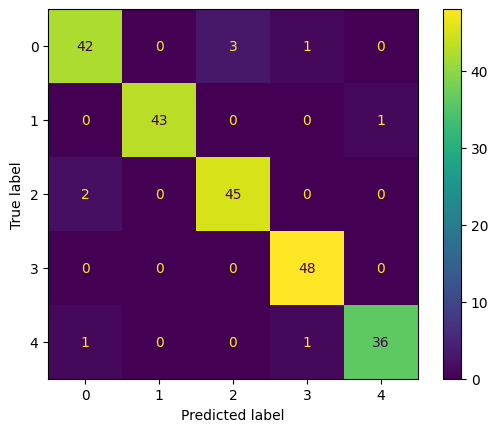

In [24]:
# Creating a visually appealing confusion matrix
#Category mappings ==> 'business': 0,'entertainment': 1,'politics': 2,'sport': 3,'tech': 4
plt.figure(figsize=(8, 8))
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=logistic_reg.classes_)
cm_display.plot()
plt.show()

# Deep Learning – Transformer Model

## Loading a pre-trained Transformer model

In [25]:
pre_trained_model = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(pre_trained_model)
model = AutoModelForSequenceClassification.from_pretrained(
    pre_trained_model,
    num_labels=5
)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
